# B-CNN con Compact Bilinear Pooling para clasificacion de aves CUB-200-2011

Modelo "custom basado en paper": **Bilinear CNN** de Lin, RoyChowdhury & Maji (ICCV 2015) - [paper](https://openaccess.thecvf.com/content_iccv_2015/papers/Lin_Bilinear_CNN_Models_ICCV_2015_paper.pdf) - con **Compact Bilinear Pooling** de Gao et al. (CVPR 2016) - [paper](https://openaccess.thecvf.com/content_cvpr_2016/papers/Gao_Compact_Bilinear_Pooling_CVPR_2016_paper.pdf).

La B-CNN pasa la imagen por dos extractores CNN (A y B) y en **cada ubicacion espacial** toma el **producto externo** de sus vectores de features; con *pooling* sobre todas las ubicaciones arma un descriptor que captura interacciones de segundo orden entre canales (clave en *fine-grained*). Usamos la version **simetrica [D, D]**: A y B son el **mismo** backbone (VGG-16 truncado en `conv5_3`, 512 canales), con pesos de ImageNet.

El bilineal completo daria un vector de `512 x 512 = 262.144` dims y un clasificador de ~52M params: **inviable en 4GB** (da OOM). Por eso usamos **Compact Bilinear Pooling (Tensor Sketch)**, que aproxima el mismo descriptor en solo `d = 8192` dims (clasificador de ~1,6M params) **sin construir nunca la matriz `512x512`**, con accuracy casi identica (correlacion ~0.999 con el bilineal real). Lo implementamos **a mano** (Count Sketch + convolucion circular via FFT).

> **Adaptaciones a 4GB de VRAM (RTX 3050):** Compact Bilinear Pooling (d=8192), *mixed precision* (`float16`), `batch_size=8` e imagenes a `224x224` (el paper de B-CNN usa `448x448`, inviable aca).

## 1. Importar librerias y configurar parametros

Activamos *mixed precision* y definimos, ademas del `MODO` de experimento (igual que en los otros modelos), el parametro `CBP_DIM`: la dimension del descriptor de **Compact Bilinear Pooling** (8192 por defecto), que reemplaza al bilineal completo de 262.144 dims y mantiene el modelo dentro de los 4GB.

In [ ]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
DATASET_NAME = "caltech_birds2011"
IMG_SIZE = 224         
BATCH_SIZE = 16         
EPOCHS = 30
LEARNING_RATE = 5e-4   
DROPOUT_RATE = 0.50    

# Mixed precision: el backbone corre en float16 (menos memoria, mas rapido en la
# RTX 3050/Ampere). La capa de pooling y el Dense final se fuerzan a float32 por
# estabilidad numerica (la FFT requiere float32). En Keras 3 el optimizer se
# envuelve solo en un LossScaleOptimizer al compilar.
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Policy de computo:", tf.keras.mixed_precision.global_policy().name)

# --- Condicion del experimento (mismo esquema que EfficientNetB2 / Xception) ---
MODO = "transfer"  # "transfer" | "augmentation" | "finetuning"
USAR_AUGMENTATION = MODO in ("augmentation", "finetuning")
HACER_FINETUNING = MODO == "finetuning"

# --- Compact Bilinear Pooling: dimension del descriptor compacto (Tensor Sketch) ---
# El bilineal completo serian 512*512 = 262144 dims (OOM en 4GB); CBP lo aproxima
# en CBP_DIM dims. 8192 es el valor estandar del paper (correlacion ~0.999).
CBP_DIM = 8192

# Hiperparametros de la fase de fine-tuning (solo si MODO == "finetuning").
FINETUNE_LR = 1e-5            # LR bajo para no destruir los pesos ImageNet de conv5
FINETUNE_EPOCHS = 20
FINETUNE_BLOQUE = "block5"   # descongelamos solo el ultimo bloque conv de VGG-16

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Generacion de rutas para guardar los datasets, resultados y modelos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "modelos" else Path.cwd()
TFDS_DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "resultados"
MODELS_DIR = PROJECT_ROOT / "modelos_guardados"

TFDS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Modo de experimento:", MODO)
print("Augmentation:", USAR_AUGMENTATION, "| Fine-tuning:", HACER_FINETUNING)
print("Compact Bilinear Pooling dim:", CBP_DIM)
print("Dataset cache:", TFDS_DATA_DIR)

Policy de computo: mixed_float16
Modo de experimento: transfer
Augmentation: False | Fine-tuning: False
Compact Bilinear Pooling dim: 8192
Dataset cache: /home/felipe_r/proyectos/TP3-CNN/dataset


## 2. Cargar el dataset

Usamos splits directos de TFDS (los mismos que en los otros modelos): el split oficial `train` se divide en entrenamiento (80%) y validacion (20%), y el split oficial `test` queda para la evaluacion final.

In [34]:
TRAIN_SPLIT = "train[:80%]"
VAL_SPLIT = "train[80%:]"
TEST_SPLIT = "test"
print("Splits:", TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    DATASET_NAME,
    split=[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print(f"Clases de pajaros: {num_classes}")
print(f"Cantidad de datos para Entrenar: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Cantidad de datos para Validacion: {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Cantidad de datos para Test: {tf.data.experimental.cardinality(ds_test_raw).numpy()}")

Splits: train[:80%] train[80%:] test
Clases de pajaros: 200
Cantidad de datos para Entrenar: 4795
Cantidad de datos para Validacion: 1199
Cantidad de datos para Test: 5794


## 3. Visualizar algunas imagenes del dataset

In [ ]:
plt.figure(figsize=(12, 6))
for i, (imagen, etiqueta) in enumerate(ds_train_raw.take(6)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(imagen)
    plt.title(class_names[int(etiqueta.numpy())], fontsize=9)
    plt.axis("off")
plt.tight_layout()

## 4. Funcion para graficar el entrenamiento

In [35]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["accuracy"], label="train")
    axes[0].plot(history_df["val_accuracy"], label="validation")
    axes[0].set_title("Accuracy (Precision)")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Precision")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train")
    axes[1].plot(history_df["val_loss"], label="validation")
    axes[1].set_title("Funcion de Loss")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Error")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return history_df

## 5. Preprocesar datos

CUB tiene imagenes de tamaños variables. Usamos `resize_with_pad` para llevarlas a `224x224` sin deformar la proporcion. A diferencia de EfficientNet, el `preprocess_input` de VGG-16 **no** esta dentro del modelo, asi que lo aplicamos aca, en el pipeline `tf.data`: convierte RGB->BGR y resta la media de ImageNet (estilo caffe), dejando la imagen aproximadamente en `[-128, 128]`.

In [36]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(imagen, etiqueta):
    """
    Redimensiona con padding, castea a float32 y aplica el preprocess de VGG-16.

    Args:
        imagen: Tensor con la imagen original de CUB-200-2011.
        etiqueta: Indice entero de la clase.

    Returns:
        tuple: Imagen preprocesada (BGR, media restada) y etiqueta entera.
    """
    imagen = tf.image.resize_with_pad(imagen, IMG_SIZE, IMG_SIZE)
    imagen = tf.cast(imagen, tf.float32)
    imagen = preprocess_input(imagen)  # VGG-16: RGB->BGR + resta de media ImageNet
    etiqueta = tf.cast(etiqueta, tf.int32)
    return imagen, etiqueta


def prepare_dataset(dataset, training=False):
    """
    Aplica el preprocesamiento a un split. En entrenamiento, baraja antes de
    armar los batches. Prefetch solapa la preparacion del siguiente batch.

    Args:
        dataset: Dataset de TensorFlow con pares (imagen, etiqueta).
        training: Si es True, aplica shuffle para entrenamiento.

    Returns:
        tf.data.Dataset listo para model.fit / model.evaluate.
    """
    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds = prepare_dataset(ds_val_raw)
test_ds = prepare_dataset(ds_test_raw)

for images, labels in train_ds.take(1):
    print("Batch de imagenes:", images.shape)
    print("Batch de etiquetas:", labels.shape)
    print("Label dtype:", labels.dtype)

Batch de imagenes: (8, 224, 224, 3)
Batch de etiquetas: (8,)
Label dtype: <dtype: 'int32'>


## 5.b Data augmentation

Aplicamos *data augmentation* **geometrico** como capas de Keras dentro del modelo, por lo que **solo se activa en entrenamiento** (`model.fit`) y queda inactivo en validacion, evaluacion y prediccion. Empezamos con transformaciones geometricas, que no dependen de la escala de intensidad y por lo tanto funcionan bien aunque se apliquen despues del `preprocess_input` (sobre la imagen ya con la media restada):

- `RandomFlip("horizontal")`: refleja izquierda-derecha (un ave no aparece boca abajo, por eso no usamos flip vertical).
- `RandomRotation(0.15)`: rota levemente.
- `RandomZoom(0.15)`: acerca/aleja levemente.

Usamos `fill_mode="reflect"` para no dejar bordes con relleno.

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15, fill_mode="reflect"),
        layers.RandomZoom(0.15, fill_mode="reflect"),
    ],
    name="data_augmentation",
)

In [ ]:
# Visualizamos el efecto geometrico sobre una imagen en rango [0, 255] (sin el
# preprocess de VGG, solo para que se vea natural). En el modelo real la misma
# augmentation se aplica despues de preprocess_input; la geometria es identica.
for sample_image, _ in ds_train_raw.take(1):
    sample = tf.image.resize_with_pad(tf.cast(sample_image, tf.float32), IMG_SIZE, IMG_SIZE)

plt.figure(figsize=(12, 6))
for i in range(6):
    augmented = data_augmentation(tf.expand_dims(sample, 0), training=True)
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 255).astype("uint8"))
    plt.axis("off")
plt.suptitle("Ejemplos de data augmentation (geometrico)")
plt.tight_layout()
plt.show()

## 6. Capa de Compact Bilinear Pooling (implementada a mano)



In [37]:
@tf.keras.utils.register_keras_serializable(package="bcnn")
class CompactBilinearPooling(layers.Layer):
    """Compact Bilinear Pooling (Tensor Sketch) - Gao et al. CVPR 2016.

    Aproxima el pooling bilineal simetrico [D, D] en `output_dim` dimensiones
    (en vez de C*C) via Count Sketch + convolucion circular (FFT), sin construir
    nunca la matriz C x C.

    Entrada: (B, H, W, C)   Salida: (B, output_dim) con signed sqrt + L2.
    """

    def __init__(self, output_dim=8192, eps=1e-12, seed=42, **kwargs):
        super().__init__(**kwargs)
        # Manejamos el dtype a mano (float32 + FFT); desactivamos el autocast de
        # mixed precision para evitar el warning de casteo complex64 -> float32.
        self.autocast = False
        self.output_dim = output_dim
        self.eps = eps
        self.seed = seed

    def build(self, input_shape):
        c = int(input_shape[-1])
        d = self.output_dim
        # Hashes (a que bin va cada canal) y signos (+-1), fijos. Se regeneran de
        # forma determinista con la semilla, asi se reconstruyen identicos al
        # recargar el modelo (build corre con el mismo seed) -> no hace falta
        # guardarlos como pesos.
        rng = np.random.RandomState(self.seed)
        self._h1 = tf.constant(rng.randint(0, d, size=c), dtype=tf.int64)
        self._s1 = tf.constant(rng.choice([-1.0, 1.0], size=c), dtype=tf.float32)
        self._h2 = tf.constant(rng.randint(0, d, size=c), dtype=tf.int64)
        self._s2 = tf.constant(rng.choice([-1.0, 1.0], size=c), dtype=tf.float32)
        super().build(input_shape)

    def _count_sketch(self, x, h, s):
        # x: (N, C) -> psi: (N, d), con psi[n, j] = sum_{k: h[k]=j} s[k]*x[n, k].
        # Lo hacemos con unsorted_segment_sum sobre el eje de canales (sin matriz densa).
        sx = x * s
        psi_t = tf.math.unsorted_segment_sum(tf.transpose(sx), h, self.output_dim)
        return tf.transpose(psi_t)

    def call(self, features):
        features = tf.cast(features, tf.float32)   # la FFT requiere float32/complex64
        shp = tf.shape(features)
        c = features.shape[-1]                      # canales C (estatico)
        x = tf.reshape(features, [-1, c])           # (N, C), N = B*H*W

        # Dos count sketches independientes de los features.
        psi1 = self._count_sketch(x, self._h1, self._s1)
        psi2 = self._count_sketch(x, self._h2, self._s2)

        # Convolucion circular de los count sketches = count sketch del producto
        # externo x⊗x (teorema de convolucion: producto en el dominio de frecuencia).
        fft1 = tf.signal.fft(tf.cast(psi1, tf.complex64))
        fft2 = tf.signal.fft(tf.cast(psi2, tf.complex64))
        cbp = tf.math.real(tf.signal.ifft(fft1 * fft2))   # (N, d)

        # Average pooling sobre las ubicaciones espaciales H*W.
        cbp = tf.reshape(cbp, [shp[0], shp[1] * shp[2], self.output_dim])
        cbp = tf.reduce_mean(cbp, axis=1)                 # (B, d)

        # Signed square root + L2 (igual que en la B-CNN clasica).
        cbp = tf.sign(cbp) * tf.sqrt(tf.abs(cbp) + self.eps)
        cbp = tf.nn.l2_normalize(cbp, axis=-1, epsilon=self.eps)
        return cbp

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.output_dim)

    def get_config(self):
        config = super().get_config()
        config.update({"output_dim": self.output_dim, "eps": self.eps, "seed": self.seed})
        return config

## 7. Construir el modelo B-CNN (con Compact Bilinear Pooling)

`build_bcnn` esta parametrizada por `backbone_fn` para poder intercambiar el backbone facilmente. Truncamos VGG-16 en `block5_conv3` (`14x14x512`, sin las fully-connected) con pesos de ImageNet. El flujo es:

`Input -> [augmentation] -> backbone congelado -> CompactBilinearPooling(d) -> Dropout -> Dense(200, softmax, float32)`

VGG-16 **no tiene BatchNorm**, asi que el `training=False` con que llamamos al backbone no altera su salida y la transicion congelado->fine-tuning queda limpia.

In [38]:
def build_bcnn(
    num_classes,
    img_size=IMG_SIZE,
    backbone_fn=VGG16,
    truncate_layer="block5_conv3",
    cbp_dim=CBP_DIM,
    dropout_rate=DROPOUT_RATE,
    augmentation=None,
    name="BCNN_CBP",
):
    """Arma la B-CNN simetrica [D, D] con Compact Bilinear Pooling.

    Args:
        num_classes: cantidad de clases de salida.
        backbone_fn: constructor de keras.applications (VGG16 por defecto).
        truncate_layer: capa conv donde truncamos el backbone (ultima conv).
        cbp_dim: dimension del descriptor compacto (Tensor Sketch).
        augmentation: modelo de data augmentation o None.

    Returns:
        (model, feature_extractor): el modelo completo y el backbone truncado
        (este ultimo se devuelve para poder descongelarlo en el fine-tuning).
    """
    # Backbone preentrenado en ImageNet, truncado en la ultima conv (sin top).
    base = backbone_fn(weights="imagenet", include_top=False,
                       input_shape=(img_size, img_size, 3))
    feature_extractor = Model(
        inputs=base.input,
        outputs=base.get_layer(truncate_layer).output,
        name=f"{base.name}_trunc",
    )
    feature_extractor.trainable = False  # fase 1: backbone congelado (tipo TL)

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = augmentation(inputs) if augmentation is not None else inputs

    # VGG-16 no tiene BatchNorm: training=False no cambia su salida, lo pasamos
    # por consistencia con el patron de los otros notebooks.
    x = feature_extractor(x, training=False)

    # Compact Bilinear Pooling (Tensor Sketch) hecho a mano.
    x = CompactBilinearPooling(output_dim=cbp_dim, seed=SEED,
                               name="compact_bilinear_pooling")(x)

    # Clasificador lineal. Dropout para regularizar el descriptor compacto.
    x = layers.Dropout(dropout_rate)(x)
    # dtype="float32" en la salida: requisito de mixed precision.
    outputs = layers.Dense(num_classes, activation="softmax",
                           dtype="float32", name="predicciones")(x)

    return Model(inputs, outputs, name=name), feature_extractor


model, feature_extractor = build_bcnn(
    num_classes,
    augmentation=data_augmentation if USAR_AUGMENTATION else None,
    name=f"BCNN_{MODO}",
)
model.summary()

Model: "BCNN_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_trunc (Functional)        │ (None, 14, 14, 512)    │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_bilinear_pooling        │ (None, 8192)           │             0 │
│ (CompactBilinearPooling)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicciones (Dense)            │ (None, 200)            │     1,638,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,353,288 (62.38 MB)

 Trainable params: 1,638,600 (6.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 8. Compilar y entrenar (fase 1: backbone congelado)

Con el backbone congelado entrenamos solo el clasificador lineal sobre el descriptor bilineal (analogo al Transfer Learning de los otros modelos). Optimizer Adam, `sparse_categorical_crossentropy` (labels enteras) y `EarlyStopping` sobre `val_loss`.

Epoch 1/30


600/600 ━━━━━━━━━━━━━━━━━━━━ 63s 88ms/step - accuracy: 0.1030 - loss: 5.1044 - val_accuracy: 0.2477 - val_loss: 4.8623
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.4509 - loss: 4.5235 - val_accuracy: 0.3536 - val_loss: 4.4300
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.5946 - loss: 4.0288 - val_accuracy: 0.3987 - val_loss: 4.0555
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.6638 - loss: 3.5939 - val_accuracy: 0.4287 - val_loss: 3.7329
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.7095 - loss: 3.2133 - val_accuracy: 0.4570 - val_loss: 3.4550
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.7395 - loss: 2.8805 - val_accuracy: 0.4696 - val_loss: 3.2180
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.7656 - loss: 2.5929 - val_accuracy: 0.4846 - val_loss: 3.0149
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7852 - loss: 2.3444 - val_accurac

2026-06-30 00:09:48.122081: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 4816928 bytes after encountering the first element of size 4816928 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


600/600 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.9420 - loss: 0.7795 - val_accuracy: 0.5738 - val_loss: 1.8553
Epoch 23/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9447 - loss: 0.7290 - val_accuracy: 0.5755 - val_loss: 1.8295
Epoch 24/30
  2/600 ━━━━━━━━━━━━━━━━━━━━ 54s 91ms/step - accuracy: 1.0000 - loss: 0.6576

2026-06-30 00:10:53.828677: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 4816928 bytes after encountering the first element of size 4816928 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.9535 - loss: 0.6811 - val_accuracy: 0.5771 - val_loss: 1.8061
Epoch 25/30


2026-06-30 00:11:37.105793: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 4816928 bytes after encountering the first element of size 4816928 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


600/600 ━━━━━━━━━━━━━━━━━━━━ 46s 50ms/step - accuracy: 0.9583 - loss: 0.6383 - val_accuracy: 0.5788 - val_loss: 1.7846
Epoch 26/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.9650 - loss: 0.5970 - val_accuracy: 0.5780 - val_loss: 1.7650
Epoch 27/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.9708 - loss: 0.5599 - val_accuracy: 0.5830 - val_loss: 1.7466
Epoch 28/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.9721 - loss: 0.5225 - val_accuracy: 0.5863 - val_loss: 1.7283
Epoch 29/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.9789 - loss: 0.4915 - val_accuracy: 0.5805 - val_loss: 1.7131
Epoch 30/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.9814 - loss: 0.4593 - val_accuracy: 0.5822 - val_loss: 1.6968


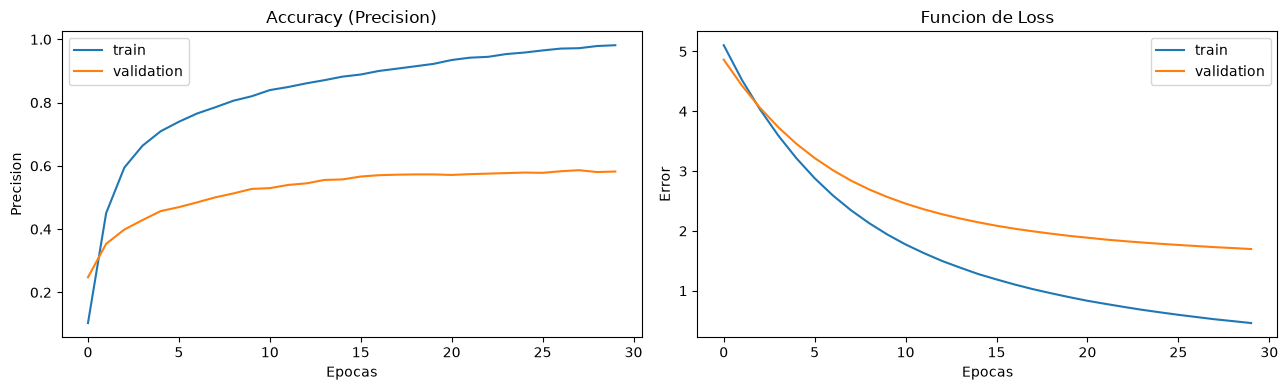

,accuracy,loss,val_accuracy,val_loss
0,0.103024,5.104369,0.247706,4.862318
1,0.450886,4.523453,0.353628,4.430047
2,0.594578,4.028849,0.398666,4.055468
3,0.663816,3.593903,0.428691,3.732918
4,0.709489,3.213274,0.457048,3.454969
5,0.739520,2.880490,0.469558,3.217974
6,0.765589,2.592857,0.484570,3.014934
7,0.785193,2.344393,0.500417,2.840482
8,0.806048,2.128652,0.512927,2.692626
9,0.820021,1.938997,0.527106,2.566186


In [39]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)

## 9. Fine-tuning (fase 2)

Solo se ejecuta si `MODO == "finetuning"`. Partiendo de la cabeza ya entrenada, descongelamos el backbone y dejamos entrenable **solo el ultimo bloque conv** (`block5`) de VGG-16; el resto sigue con los pesos de ImageNet. Recompilamos con un learning rate bajo (`FINETUNE_LR = 1e-5`) y continuamos con `initial_epoch` para que la numeracion de epocas sea continua.

> Si aparece `ResourceExhaustedError` en esta fase (mas pesada que la fase 1), bajar `BATCH_SIZE` a 4 o reducir `CBP_DIM` (p. ej. 4096).

In [ ]:
if HACER_FINETUNING:
    # Descongelamos el backbone y dejamos entrenable solo el ultimo bloque conv.
    feature_extractor.trainable = True
    for layer in feature_extractor.layers:
        layer.trainable = layer.name.startswith(FINETUNE_BLOQUE)

    # VGG-16 no tiene BatchNorm, asi que no hay capas BN que reconfigurar.
    model.compile(
        optimizer=Adam(learning_rate=FINETUNE_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    entrenables = [l.name for l in feature_extractor.layers if l.trainable]
    print("Capas del backbone que se afinan:", entrenables)

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=history.epoch[-1] + 1,
        epochs=history.epoch[-1] + 1 + FINETUNE_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    plot_training_history(history_ft)

## 10. Evaluacion en el conjunto de prueba

In [40]:
test_metrics = model.evaluate(test_ds, verbose=1)

print("Metricas en conjunto de prueba:")
for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")

725/725 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.6072 - loss: 1.6553
Metricas en conjunto de prueba:
loss: 1.6553
compile_metrics: 0.6072


## 11. Matriz de confusion y reporte de clasificacion

In [41]:
# test_ds no esta barajado; asi y_true y y_pred quedan alineados.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred = model.predict(test_ds, verbose=1).argmax(axis=1)

test_accuracy_from_predictions = np.mean(y_true == y_pred)
print(f"Accuracy en test ({model.name}): {test_accuracy_from_predictions:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

2026-06-30 00:25:57.554845: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


725/725 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step
Accuracy en test (BCNN_transfer): 0.6072


,precision,recall,f1-score,support
0,0.548387,0.566667,0.557377,30.00000
1,0.615385,0.533333,0.571429,30.00000
2,0.642857,0.642857,0.642857,28.00000
3,0.648649,0.800000,0.716418,30.00000
4,0.588235,0.714286,0.645161,14.00000
...,...,...,...,...
198,0.590909,0.866667,0.702703,30.00000
199,0.800000,0.800000,0.800000,30.00000
accuracy,0.607180,0.607180,0.607180,0.60718
macro avg,0.616416,0.610331,0.607364,5794.00000


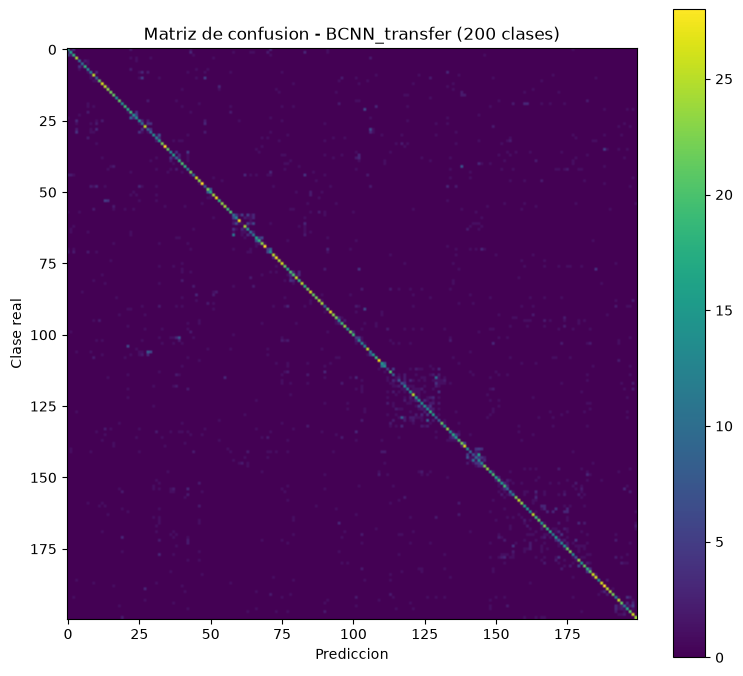

Top 10 pares mas confundidos:
  '142' confundida con '144': 16 veces
  '65' confundida con '58': 11 veces
  '144' confundida con '142': 10 veces
  '115' confundida con '129': 10 veces
  '111' confundida con '110': 10 veces
  '70' confundida con '71': 9 veces
  '24' confundida con '22': 9 veces
  '130' confundida con '126': 8 veces
  '129' confundida con '117': 8 veces
  '110' confundida con '111': 8 veces


In [42]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Matriz de confusion - {model.name} ({len(class_names)} clases)")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confundidos = [
    (cm_sin_diagonal[i, j], i, j)
    for i in range(len(cm_sin_diagonal))
    for j in range(len(cm_sin_diagonal))
    if cm_sin_diagonal[i, j] > 0
]
pares_confundidos.sort(reverse=True)

print("Top 10 pares mas confundidos:")
for cantidad, real_idx, pred_idx in pares_confundidos[:10]:
    print(f"  '{class_names[real_idx]}' confundida con '{class_names[pred_idx]}': {cantidad} veces")

## 11.b Diccionario indice -> clase

Mapea cada entero a su nombre de especie. No depende del modelo entrenado: usa `class_names` y `pares_confundidos`, asi que se puede correr sin reentrenar.

In [ ]:
idx_to_class = dict(enumerate(class_names))

top_n = 10
indices_confundidos = sorted(
    {i for _, real_idx, pred_idx in pares_confundidos[:top_n] for i in (real_idx, pred_idx)}
)
clases_confundidas = {idx: idx_to_class[idx] for idx in indices_confundidos}

print(f"Clases involucradas en el top {top_n} de pares confundidos:")
for idx, nombre in clases_confundidas.items():
    print(f"  {idx}: {nombre}")

## 12. Guardar resultados y modelo

Guardamos con el mismo esquema que los otros modelos (sufijo segun `MODO`) para que el notebook de comparacion pueda leer todo de forma uniforme: `_results.csv`, `_history.csv`, `_preds.csv` (para regenerar la matriz de confusion sin reentrenar) y el `.keras`.

In [ ]:
# History completo: fase 1 (+ fase 2 de fine-tuning si corresponde).
frames = [pd.DataFrame(history.history)]
if HACER_FINETUNING:
    frames.append(pd.DataFrame(history_ft.history))
history_full_df = pd.concat(frames, ignore_index=True)

results = {
    "modelo": "BCNN_VGG16_CBP",
    "modo": MODO,
    "dataset": DATASET_NAME,
    "train_split": TRAIN_SPLIT,
    "val_split": VAL_SPLIT,
    "test_split": TEST_SPLIT,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "augmentation": USAR_AUGMENTATION,
    "cbp_dim": CBP_DIM,
    "epochs_configuradas": EPOCHS,
    "epochs_ejecutadas": len(history_full_df),
    "learning_rate": LEARNING_RATE,
    "finetune_lr": FINETUNE_LR if HACER_FINETUNING else None,
    "finetune_bloque": FINETUNE_BLOQUE if HACER_FINETUNING else None,
    "test_loss": test_metrics[0],
    "test_accuracy": test_metrics[1],
}

results_df = pd.DataFrame([results])
display(results_df)

results_path = RESULTS_DIR / f"bcnn_{MODO}_results.csv"
history_path = RESULTS_DIR / f"bcnn_{MODO}_history.csv"
preds_path = RESULTS_DIR / f"bcnn_{MODO}_preds.csv"
model_path = MODELS_DIR / f"bcnn_{MODO}.keras"

results_df.to_csv(results_path, index=False)
history_full_df.to_csv(history_path, index=False)
# Predicciones por muestra del test: con esto se regenera la matriz de confusion,
# el reporte por clase y los pares confundidos sin volver a correr el modelo.
pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(preds_path, index=False)
model.save(model_path)

# class_names es el mismo para todas las corridas; lo guardamos una sola vez.
class_names_path = RESULTS_DIR / "class_names.csv"
if not class_names_path.exists():
    pd.DataFrame({"idx": range(len(class_names)), "clase": class_names}).to_csv(
        class_names_path, index=False
    )

print("Resultados guardados en:", results_path)
print("History guardado en:", history_path)
print("Predicciones guardadas en:", preds_path)
print("Modelo guardado en:", model_path)